# Modelagem Supervisionada — Predição de Alfabetização Municipal
### Tech Challenge Fase 3

Este notebook documenta, de ponta a ponta, a pipeline de Machine Learning construída em
`src/preprocessing/` e `src/modeling/`, incluindo o raciocínio por trás de cada decisão.
O código "de produção" vive em `src/` (reutilizável via `python -m ...` ou import); aqui ele é
executado e narrado para fins de revisão/aprendizado.

## 1. Reformulação do problema

O enunciado pede um modelo que preveja **se um aluno será alfabetizado ou não**. A camada Gold
da Fase 2, no entanto, está agregada em **município × ano** — não existe granularidade de aluno
individual disponível. Reformulamos o problema, mantendo a essência (prever risco de
não-alfabetização para apoiar decisão pública), para o nível de granularidade real dos dados:

> **Alvo (`alfabetizacao_adequada`):** o município atingiu (1) ou não atingiu (0) a meta de
> alfabetização estipulada para aquele ano, com base no indicador oficial (`gap_meta_percentual
> >= 0`).

Essa reformulação está alinhada às próprias perguntas de negócio do desafio ("quais municípios
apresentam maior risco educacional", "como prever municípios que podem não atingir metas
futuras").

## 2. Tratamento de Data Leakage

Na EDA (`01_eda.ipynb`, seção 4) identificamos que `indicador_alfabetizacao_percentual` e
`proficiencia_media_saeb` do mesmo ano são fortemente correlacionadas com o alvo — e
`gap_meta_percentual` o define algebricamente (`indicador - meta`). Usá-las como features do ano
corrente seria vazar a resposta para o modelo.

**Solução:** `src/preprocessing/build_features.py` remove essas três colunas do ano corrente e
cria, no lugar, **features defasadas (lag 1 ano)** por município: o valor do ano anterior de cada
uma delas, mais uma feature de tendência (`indicador_tendencia_lag1`). Isso preserva sinal
preditivo real (a EDA mostrou forte autocorrelação temporal) sem revelar o resultado do ano que
queremos prever.

In [1]:
import sys
sys.path.append("..")

from src.preprocessing.build_features import build

base = build()
base.head()

[ok] base analítica: 1536 linhas, 18 colunas -> /home/user/tech_challenge3/data/processed/base_analitica.parquet
     anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
     balanceamento do alvo:
alfabetizacao_adequada
0    0.686198
1    0.313802
Name: proportion, dtype: float64


,ano,id_municipio,nome_municipio,sigla_uf,nome_uf,regiao,total_estudantes_avaliados,total_escolas_avaliadas,meta_percentual,alfabetizacao_adequada,indicador_alfabetizacao_percentual_lag1,proficiencia_media_saeb_lag1,gap_meta_percentual_lag1,meta_percentual_lag1,total_estudantes_avaliados_lag1,total_escolas_avaliadas_lag1,alfabetizacao_adequada_lag1,indicador_tendencia_lag1
0,2022,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,171,3,51.1,0,33.5,722.4,-11.5,45.0,215,4,0.0,NaN
1,2023,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,165,2,57.2,0,34.2,729.1,-16.9,51.1,171,3,0.0,0.7
2,2024,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,179,2,63.3,0,40.0,737.5,-17.2,57.2,165,2,0.0,5.8
3,2022,1100031,Cabixi,RO,Rondônia,Norte,163,2,51.1,0,35.6,727.6,-9.4,45.0,286,4,0.0,NaN
4,2023,1100031,Cabixi,RO,Rondônia,Norte,273,4,57.2,0,47.6,753.9,-3.5,51.1,163,2,0.0,12.0


## 3. Engenharia de atributos e pipeline de pré-processamento

A pipeline (`src/modeling/train.py::build_preprocessor`) é um único `sklearn.Pipeline` /
`ColumnTransformer` que integra:

- **Imputação de numéricas** (mediana) — necessária pois municípios do primeiro ano de histórico
  (2022) não têm `indicador_tendencia_lag1` (precisa de 2 anos de defasagem).
- **Padronização (StandardScaler)** das numéricas.
- **Imputação de categóricas** (moda) + **One-Hot Encoding** de `sigla_uf`.
- **Integração direta ao modelo**: todo o pré-processamento é um `step` do mesmo `Pipeline` que
  contém o classificador — evitando qualquer vazamento entre fit de treino e transform de teste
  (o `fit` do imputer/scaler acontece **somente** nos dados de treino, dentro do `.fit()` da
  pipeline completa).

Uma decisão importante: **excluímos `regiao`** das features. Ela é uma agregação determinística
de `sigla_uf` (nested) — incluir as duas geraria colinearidade perfeita entre grupos de dummies,
inflando/instabilizando os coeficientes da regressão logística e prejudicando a interpretabilidade
(SHAP). Mantivemos apenas `sigla_uf`, mais granular; leituras por região são obtidas agregando as
UFs em análise posterior (seção 6 abaixo).

## 4. Validação: split temporal + GroupKFold

- **Split temporal**: treino = 2022–2023 (com lag de 2021–2022), teste = 2024 (holdout). Isso
  simula o uso real do modelo — prever o futuro a partir do passado — em vez de um split aleatório
  que misturaria "futuro" e "passado" arbitrariamente.
- **GroupKFold por município** dentro do treino, usada no `RandomizedSearchCV` para tuning de
  hiperparâmetros. Evita que o mesmo município apareça em fold de treino e validação em anos
  diferentes (o que inflaria artificialmente a métrica de validação, já que municípios têm
  características estruturais estáveis ano a ano).
- **Métrica de otimização**: ROC-AUC (robusta ao desbalanceamento do alvo, ~68%/32%).

In [2]:
from src.modeling.train import main as train_main

train_main()

Treino: (1024, 14), Teste (holdout temporal 2024): (512, 14)
Balanceamento treino:
alfabetizacao_adequada
0    0.678711
1    0.321289
Name: proportion, dtype: float64



/home/user/tech_challenge3/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


/home/user/tech_challenge3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== logistic_regression ===
  Melhor CV ROC-AUC (GroupKFold, treino): 0.9718
  ROC-AUC (holdout 2024): 0.9643
  F1 (holdout 2024): 0.8933
  Melhores hiperparâmetros: {'model__C': 10.0}
              precision    recall  f1-score   support

           0      0.948     0.964     0.956       359
           1      0.912     0.876     0.893       153

    accuracy                          0.938       512
   macro avg      0.930     0.920     0.925       512
weighted avg      0.937     0.938     0.937       512




=== random_forest ===
  Melhor CV ROC-AUC (GroupKFold, treino): 0.9646
  ROC-AUC (holdout 2024): 0.9550
  F1 (holdout 2024): 0.8634
  Melhores hiperparâmetros: {'model__n_estimators': 600, 'model__min_samples_leaf': 1, 'model__max_depth': 8}
              precision    recall  f1-score   support

           0      0.959     0.916     0.937       359
           1      0.822     0.908     0.863       153

    accuracy                          0.914       512
   macro avg      0.891     0.912     0.900       512
weighted avg      0.918     0.914     0.915       512




=== gradient_boosting ===
  Melhor CV ROC-AUC (GroupKFold, treino): 0.9651
  ROC-AUC (holdout 2024): 0.9603
  F1 (holdout 2024): 0.8795
  Melhores hiperparâmetros: {'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05}
              precision    recall  f1-score   support

           0      0.950     0.947     0.948       359
           1      0.877     0.882     0.879       153

    accuracy                          0.928       512
   macro avg      0.913     0.915     0.914       512
weighted avg      0.928     0.928     0.928       512


>>> Modelo selecionado: logistic_regression (ROC-AUC holdout = 0.9643)

Resumo salvo em reports/model_comparison.csv:
                     cv_roc_auc  test_roc_auc   test_f1
logistic_regression    0.971767      0.964298  0.893333
random_forest          0.964617      0.955031  0.863354
gradient_boosting      0.965089      0.960284  0.879479


## 5. Resultados

Os três algoritmos (Regressão Logística, Random Forest, Gradient Boosting) atingiram ROC-AUC
muito próximo (~0.95–0.97) no holdout de 2024, e desempenho de validação cruzada (GroupKFold)
consistente com o holdout — sinal de que o modelo generaliza bem e não está overfitando aos
municípios vistos em treino.

A **Regressão Logística** foi selecionada como modelo final por apresentar o melhor F1 no holdout
mantendo ROC-AUC equivalente às alternativas mais complexas — preferimos o modelo mais simples e
interpretável quando o desempenho é equivalente (princípio da parcimônia).

In [3]:
import pandas as pd
pd.read_csv("../reports/model_comparison.csv", index_col=0)

,cv_roc_auc,test_roc_auc,test_f1
logistic_regression,0.971767,0.964298,0.893333
random_forest,0.964617,0.955031,0.863354
gradient_boosting,0.965089,0.960284,0.879479


## 6. Interpretabilidade: quais variáveis mais influenciam a predição?

In [4]:
from src.evaluation.interpret import main as interpret_main

interpret_main()

[ok] Artefatos gerados em images/ e reports/:
  - confusion_matrix.png
  - roc_curve.png
  - feature_importance.png / feature_importance.csv
  - shap_summary.png

Top 10 features mais importantes:
         feature  importance  abs_importance
cat__sigla_uf_PR    5.389415        5.389415
cat__sigla_uf_RS    5.349043        5.349043
cat__sigla_uf_RJ    4.614250        4.614250
cat__sigla_uf_MG    4.587314        4.587314
cat__sigla_uf_SC    4.456062        4.456062
cat__sigla_uf_SP    3.810067        3.810067
cat__sigla_uf_CE   -3.197595        3.197595
cat__sigla_uf_RN   -3.185825        3.185825
cat__sigla_uf_ES    3.180271        3.180271
cat__sigla_uf_PE   -3.095232        3.095232


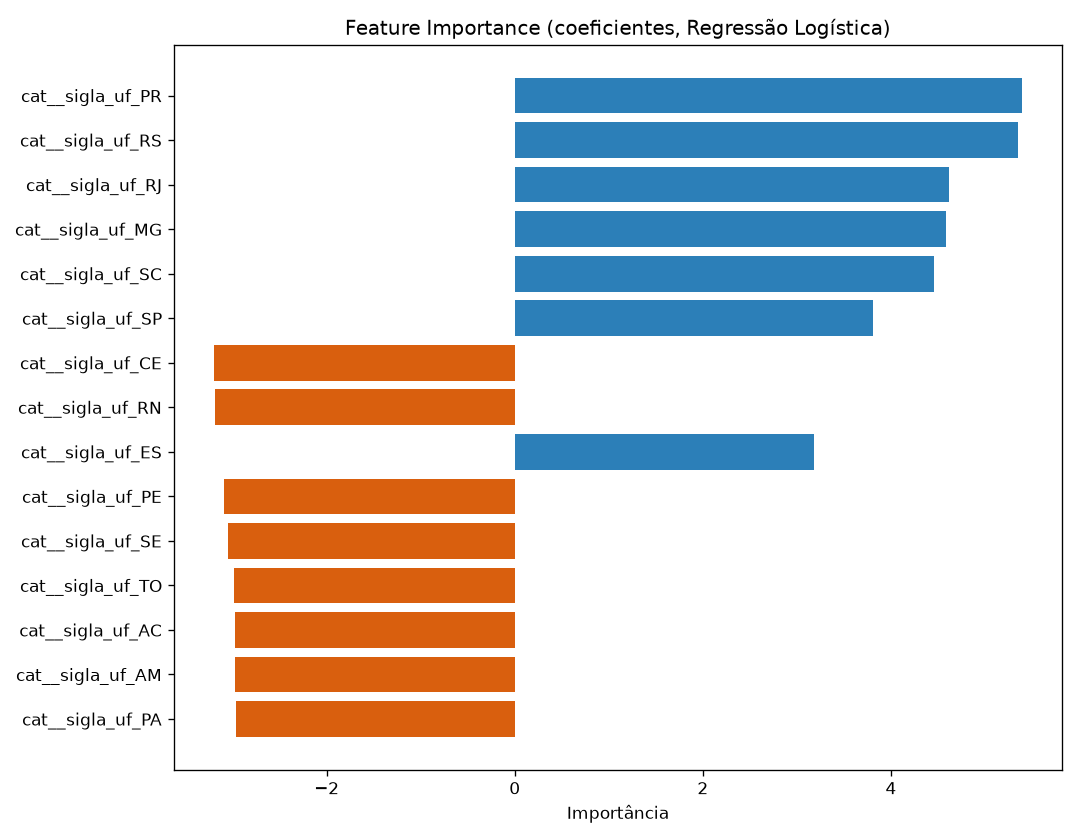

In [5]:
from PIL import Image
Image.open("../images/feature_importance.png")

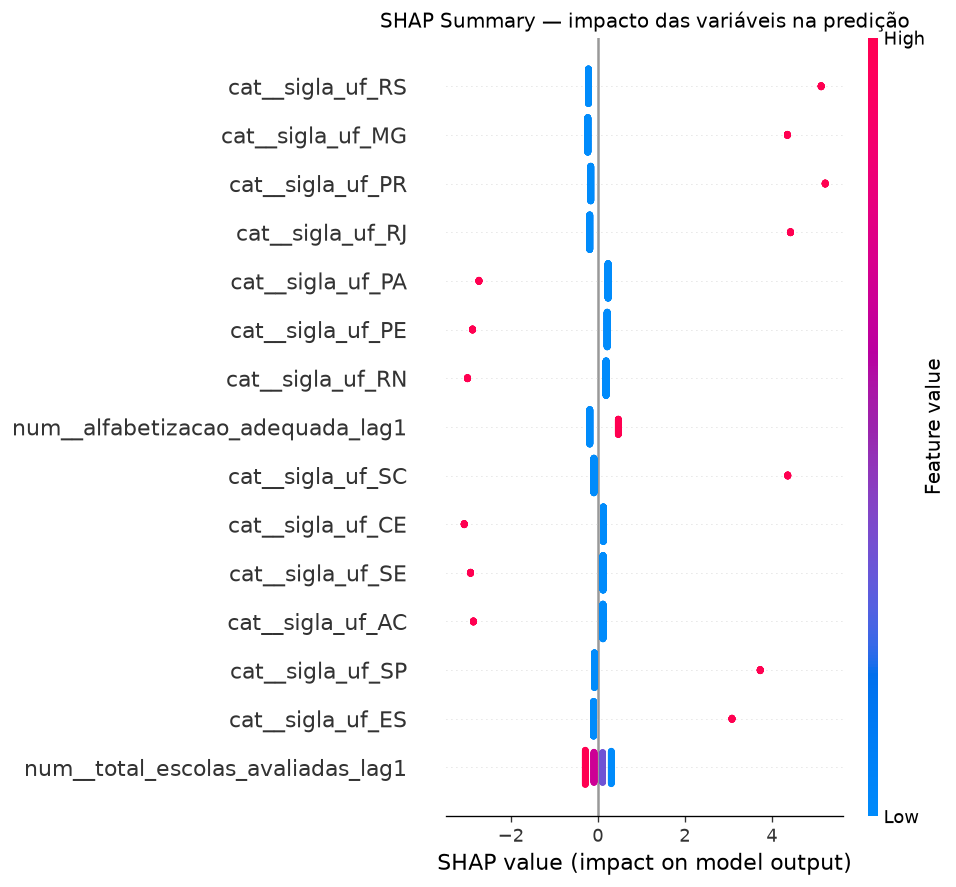

In [6]:
Image.open("../images/shap_summary.png")

**Leitura dos resultados de interpretabilidade:**

- A variável de maior peso é o **estado (UF)** — UFs do Sul/Sudeste (PR, RS, RJ, MG, SC, SP, ES)
  empurram a predição para "atingiu a meta"; UFs do Nordeste/Norte (CE, RN, PE, SE, AC, PA) empurram
  para "não atingiu" — confirma a disparidade regional levantada na hipótese H1 da EDA.
- **`alfabetizacao_adequada_lag1`** (o município atingiu a meta no ano anterior) também tem peso
  relevante e consistente: histórico recente de sucesso aumenta a probabilidade de sucesso no ano
  seguinte — confirma a hipótese H4 (autocorrelação temporal) da EDA.
- Isso indica que o principal driver do modelo é **estrutural/geográfico** (localização) somado a
  **inércia de desempenho histórico**, mais do que o porte do sistema escolar isolado.

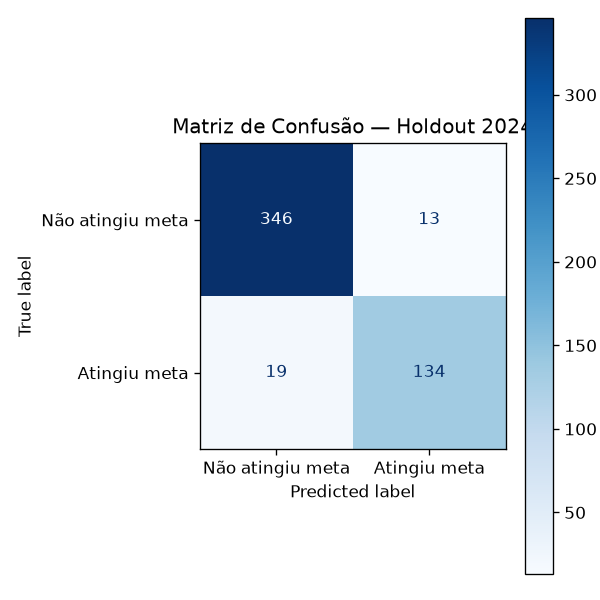

In [7]:
Image.open("../images/confusion_matrix.png")

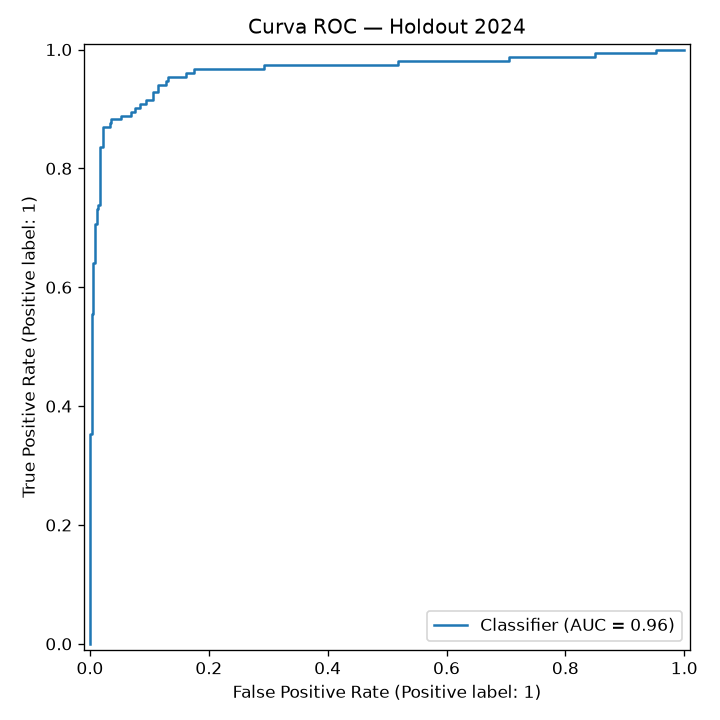

In [8]:
Image.open("../images/roc_curve.png")

## 7. Limitações

- A base cobre uma amostra de ~512 municípios (não o universo de ~5.570 municípios brasileiros) e
  apenas 4 anos (2021–2024) — o holdout temporal de 1 ano (2024) é pequeno, e a robustez do
  desempenho deveria ser reconfirmada à medida que mais anos de dados fiquem disponíveis.
- O alvo (`gap_meta_percentual >= 0`) é uma reformulação em nível de município do problema
  original (nível aluno); não substitui um modelo de predição individual, que exigiria dados de
  matrícula/aluno não presentes na camada Gold.
- Sem variáveis socioeconômicas externas (renda, IDHM, Cadastro Único) — o efeito de UF/região no
  modelo provavelmente atua como *proxy* dessas variáveis omitidas; enriquecer com IBGE/Atlas do
  Desenvolvimento Humano tende a melhorar a granularidade explicativa (ver seção "Evoluções
  Futuras" do README).